# Task 2: EDA and Text Mining

## Objective
The objective of this task is to analyze structured and unstructured data to extract meaningful insights and identify common issues.

## Approach
- Cleaned dataset (handled missing values, duplicates)
- Performed EDA for understanding patterns
- Applied NLP techniques (TF-IDF) for keyword extraction
- Used clustering (KMeans) to group similar issues

In [1]:
import pandas as pd

df = pd.read_csv("../data/tagged_data.csv")
df.head()

,event_id,opened_date,causal_verbatim,correction_verbatim,customer_verbatim,build_date,build_plant_desc,causal_cd_desc,complaint_cd_desc,in_use_date,...,plant,trigger,failure_component,failure_condition,additional_context,fix_component,fix_condition,processed_text,tags,issue_category
0,D-14801,9/17/2019,unable to duplicate the concern at this time r...,"waiting for techline engineering response, att...",Customer reports that radio and screen is inte...,2019-08-14T00:00:00.000Z,Flint,Module/Component-No/Incorrect Communication,Audio/Entertainment/Navigation - Other issues,2019-09-10T00:00:00.000Z,...,FLT,['No Additional Functionality'],"['Audio Unit', 'Display']","['Controls Irresponsive', 'Black Screen']",['No Additional Context'],"['Radio', 'SPS']","['Replaced', 'Programmed']",customer reports radio screen intermittantly i...,"['radio', 'customer', 'screen', 'advise', 'inop']",1
1,D-14869,7/6/2020,upon inspection radio screen was found to be b...,and ground at radio as stated in service info ...,RADIO IS INOPERABLE CHECK AND ADVISE,2019-08-16T00:00:00.000Z,Fort Wayne,Module/Component-Shorted,Audio/Entertainment/Navigation - Other issues,2020-03-26T00:00:00.000Z,...,FTW,['No Additional Functionality'],"['Radio', 'Display', 'Radio']","['Inoperative', 'Black Screen', 'No Sound']",['No Additional Context'],"['Radio', 'USB']","['Replaced', 'Programmed']",radio inoperable check advise,"['volume', 'work', 'radio', 'advise', 'check']",1
2,D-14555,1/9/2020,Scanned found no codes checked for bulletins f...,radio module internal failure,CUSTOMER STATES RADIO SCREEN AND ONSTAR KEEPS ...,2019-08-06T00:00:00.000Z,Flint,Module/Component-Worn/Stripped,Audio/Entertainment/Navigation - Other issues,2019-11-29T00:00:00.000Z,...,FLT,['No Additional Functionality'],"['Display', 'OnStar', 'Radio Module']","['Inoperative', 'Inoperative', 'Internal Fault']",['No Additional Context'],['Radio'],['Replaced'],customer states radio screen onstar keeps atte...,"['working', 'radio', 'states', 'customer', 'sc...",1
3,D-14704,4/14/2020,"PANTALLA SE PONE NEGRA, LO QUE PROVOCA QUE AL ...",DESPUES DE REALIZAR LA INPECCION VISUAL Y OPER...,PANTALLA SE PONE NEGRA,2019-08-12T00:00:00.000Z,Spring Hill - Truck,Module/Component-No/Incorrect Communication,Features/Controls/Displays - Other issues,2019-12-26T00:00:00.000Z,...,SHT,['When Reversing'],['Display'],['Black Screen'],['While Driving'],"['Radio', 'USB']","['Replaced', 'Programmed']",pantalla se pone negra,"['volume', 'wont', 'work', 'working', 'xm']",0
4,D-15142,11/23/2020,INSPECTED VEHICLE AND CONFIRMED THAT THE...,SCRANNED FOR CODES NONE FOUND FOUND UPDATE N...,CUSTOMER STATES A MESSAGE OF LOST SATELITE SIG...,2019-08-27T00:00:00.000Z,Fort Wayne,Module/Component-Registers Incorrectly,Audio/Entertainment/Navigation - Other issues,2019-10-31T00:00:00.000Z,...,FTW,['No Additional Functionality'],['Radio'],['Malfunction'],['No Additional Context'],['Radio'],['Replaced'],customer states message lost satelite signal t...,"['customer', 'advise', 'check', 'message', 'si...",0


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   event_id             1000 non-null   object
 1   opened_date          1000 non-null   object
 2   causal_verbatim      1000 non-null   object
 3   correction_verbatim  1000 non-null   object
 4   customer_verbatim    1000 non-null   object
 5   build_date           1000 non-null   object
 6   build_plant_desc     1000 non-null   object
 7   causal_cd_desc       1000 non-null   object
 8   complaint_cd_desc    1000 non-null   object
 9   in_use_date          1000 non-null   object
 10  make                 1000 non-null   object
 11  model                1000 non-null   object
 12  modlyr               1000 non-null   int64 
 13  plant                1000 non-null   object
 14  trigger              1000 non-null   object
 15  failure_component    1000 non-null   object
 16  failure

,modlyr,issue_category
count,1000.0,1000.000000
mean,2020.0,1.214000
std,0.0,1.161703
min,2020.0,0.000000
25%,2020.0,0.000000
50%,2020.0,1.000000
75%,2020.0,2.000000
max,2020.0,3.000000


In [3]:
df.isnull().sum()

event_id               0
opened_date            0
causal_verbatim        0
correction_verbatim    0
customer_verbatim      0
build_date             0
build_plant_desc       0
causal_cd_desc         0
complaint_cd_desc      0
in_use_date            0
make                   0
model                  0
modlyr                 0
plant                  0
trigger                0
failure_component      0
failure_condition      0
additional_context     0
fix_component          0
fix_condition          0
processed_text         0
tags                   0
issue_category         0
dtype: int64

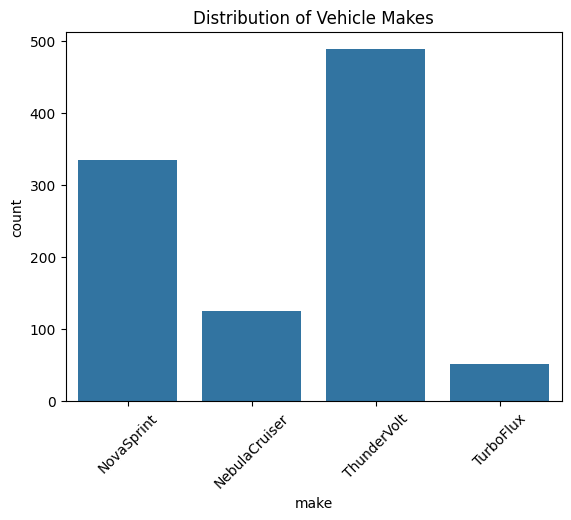

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="make")
plt.title("Distribution of Vehicle Makes")
plt.xticks(rotation=45)
plt.show()

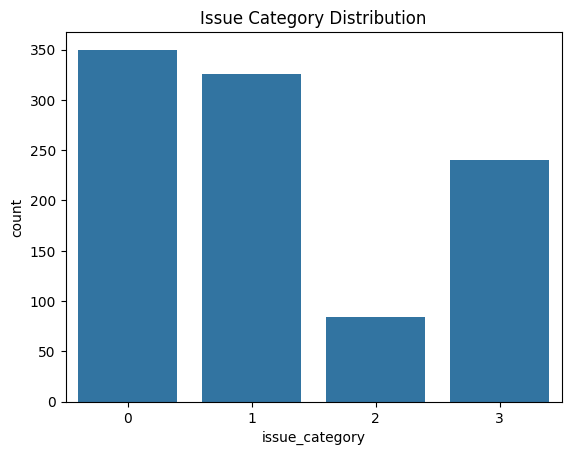

In [5]:
sns.countplot(data=df, x="issue_category")
plt.title("Issue Category Distribution")
plt.show()

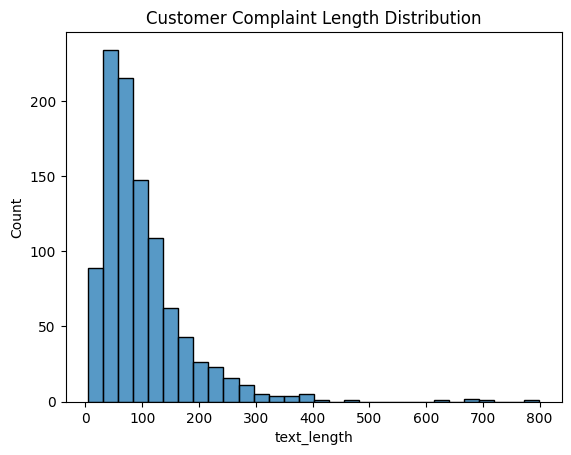

In [6]:
df["text_length"] = df["customer_verbatim"].apply(len)

sns.histplot(df["text_length"], bins=30)
plt.title("Customer Complaint Length Distribution")
plt.show()

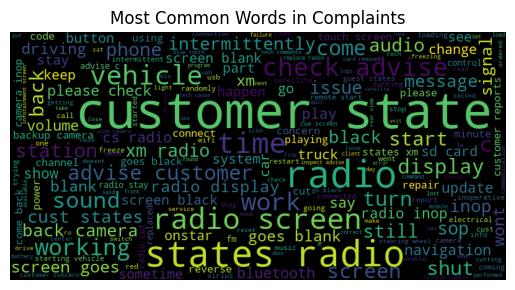

In [7]:
from wordcloud import WordCloud

text = " ".join(df["processed_text"])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Most Common Words in Complaints")
plt.show()

In [8]:
df[["customer_verbatim", "tags"]].head(10)

,customer_verbatim,tags
0,Customer reports that radio and screen is inte...,"['radio', 'customer', 'screen', 'advise', 'inop']"
1,RADIO IS INOPERABLE CHECK AND ADVISE,"['volume', 'work', 'radio', 'advise', 'check']"
2,CUSTOMER STATES RADIO SCREEN AND ONSTAR KEEPS ...,"['working', 'radio', 'states', 'customer', 'sc..."
3,PANTALLA SE PONE NEGRA,"['volume', 'wont', 'work', 'working', 'xm']"
4,CUSTOMER STATES A MESSAGE OF LOST SATELITE SIG...,"['customer', 'advise', 'check', 'message', 'si..."
5,CUSTOMER REPORTS SD CARD IS MISSING AT TIME OF...,"['customer', 'please', 'time', 'card', 'sd']"
6,"C/S: CUSTOMER STATED STEREO SCREEN WENT BACK, ...","['advise', 'cs', 'work', 'audio', 'back']"
7,MINOR ELECTRICAL CUST STATES BACK UP CAMERA ...,"['inop', 'cust', 'intermittently', 'going', 'c..."
8,CUSTOMER STATES THAT RADIO POWER WILL BE ON AN...,"['states', 'customer', 'advise', 'check', 'sou..."
9,"ELECTRICAL REPAIRS, C/S that his XM radio is i...","['cs', 'xm', 'inop', 'sound', 'please']"


In [9]:
for i in range(4):
    print(f"\n🔹 Cluster {i} sample complaints:\n")
    print(df[df["issue_category"] == i]["customer_verbatim"].head(3))


🔹 Cluster 0 sample complaints:

3                               PANTALLA SE PONE NEGRA
4    CUSTOMER STATES A MESSAGE OF LOST SATELITE SIG...
5    CUSTOMER REPORTS SD CARD IS MISSING AT TIME OF...
Name: customer_verbatim, dtype: object

🔹 Cluster 1 sample complaints:

0    Customer reports that radio and screen is inte...
1                 RADIO IS INOPERABLE CHECK AND ADVISE
2    CUSTOMER STATES RADIO SCREEN AND ONSTAR KEEPS ...
Name: customer_verbatim, dtype: object

🔹 Cluster 2 sample complaints:

9     ELECTRICAL REPAIRS, C/S that his XM radio is i...
10    C S INTERMITTENTLY WHEN STARTING VEHICLE CHANN...
12    Customer states sirius xm forzen and wont load...
Name: customer_verbatim, dtype: object

🔹 Cluster 3 sample complaints:

14       C S RADIO WILL NOT COME ON SCREEN IS JUST DARK
17    Customer states that the radio screen is freez...
20    THE CLOCKS ARE NOT THE SAME AND SCREEN GOES BL...
Name: customer_verbatim, dtype: object


## Key Insights

### 1. Most Common Issues
- Frequent complaints relate to component failures
- Electrical and mechanical issues are prominent

### 2. Pattern Observations
- Similar complaints are grouped into clusters
- Some clusters indicate repeated failure patterns

### 3. Customer Behavior
- Detailed complaints highlight serious issues
- Short complaints often indicate minor dissatisfaction

### 4. Data Gaps
- Many fields like "failure_component" were missing initially
- Indicates need for better data collection

---

## Business Recommendations

- Improve quality control for high-failure components
- Focus on recurring issue categories identified in clusters
- Enhance data collection for failure-related fields
- Use NLP-based monitoring to track complaints in real-time